In [61]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [62]:

prediction = {
    'NEUTRAL': 1,
    'BUY': 2,
    'SELL': 3
}

def replace_momentum_uo(x):
    if x > 70:
        return prediction['BUY']
    elif x < 30:
        return prediction['SELL']
    else:
        return prediction['NEUTRAL']

def replace_momentum_rsi(x):
    if x > 70:
        return prediction['SELL']
    elif x < 30:
        return prediction['BUY']
    else:
        return prediction['NEUTRAL']

def replace_momentum_wr(x):
    if x in range(-20,0):
        return prediction['SELL']
    elif x in range(-100,-80):
        return prediction['BUY']
    else:
        return prediction['NEUTRAL']

def replace_trend_cci(x):
    if x > 100:
        return prediction['SELL']
    elif x < -100:
        return prediction['BUY']
    else:
        return prediction['NEUTRAL']


In [63]:

DATA_PATH = "output_1.csv"
data = pd.read_csv(DATA_PATH).dropna(axis = 1)
data.replace(0.0,pd.NA,inplace=True)
data.dropna(inplace=True)
data.reset_index(drop=True,inplace=True)
le = LabelEncoder()
le.fit(data['Prediction'])
print(le.classes_)
# data['momentum_uo'] = data['momentum_uo'].apply(lambda x: replace_momentum_uo(x))
# data['momentum_wr'] = data['momentum_wr'].apply(lambda x: replace_momentum_wr(x))
# data['momentum_rsi'] = data['momentum_rsi'].apply(lambda x: replace_momentum_rsi(x))
# print(data.head())


['BUY' 'NEUTRAL' 'SELL']


In [64]:

X = data.iloc[:,7:-1]
y = data.iloc[:, -1]
# print(X.head())
# print(y.head())
X_train, X_test, y_train, y_test =train_test_split(
  X, y, test_size = 0.2, random_state = 24)


# Defining scoring metric for k-fold cross validation
def cv_scoring(estimator, X, y):
    return accuracy_score(y, estimator.predict(X))
 
# Initializing Models
# models = {
#     "SVC":SVC(),
#     "Random Forest":RandomForestClassifier(random_state=18)
# }
 
# # Producing cross validation score for the models
# for model_name in models:
#     model = models[model_name]
#     scores = cross_val_score(model, X, y, cv = 10, 
#                              n_jobs = -1, 
#                              scoring = cv_scoring)
#     print("=="*30)
#     print(model_name)
#     print(f"Scores: {scores}")
#     print(f"Mean Score: {np.mean(scores)}")


In [65]:

svm_model = SVC()
svm_model.fit(X_train, y_train)
preds = svm_model.predict(X_test)
 
print(f"Accuracy on train data by SVM Classifier\
: {accuracy_score(y_train, svm_model.predict(X_train))*100}")
 
print(f"Accuracy on test data by SVM Classifier\
: {accuracy_score(y_test, preds)*100}")


Accuracy on train data by SVM Classifier: 82.20187583742742
Accuracy on test data by SVM Classifier: 83.125


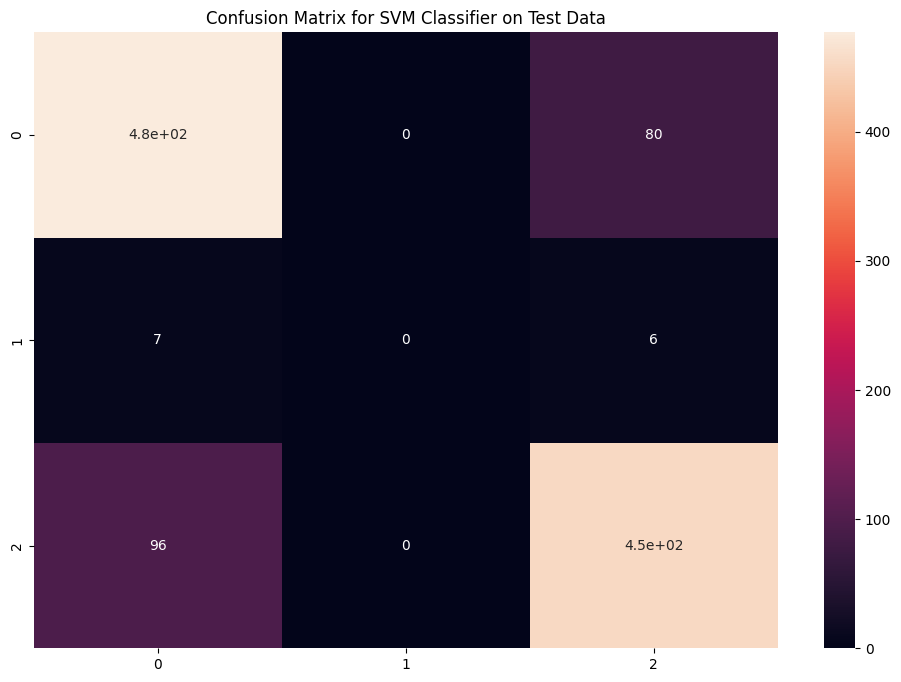

In [66]:

cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for SVM Classifier on Test Data")
plt.show()
# Checking whether the dataset is balanced or not
# data_counts = data["prognosis"].value_counts()

# temp_df = pd.DataFrame({
#     "Disease": disease_counts.index,
#     "Counts": disease_counts.values
# })

In [67]:
# Training and testing Random Forest Classifier
rf_model = RandomForestClassifier(random_state=18)
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
print(f"Accuracy on train data by Random Forest Classifier\
: {accuracy_score(y_train, rf_model.predict(X_train))*100}")
 
print(f"Accuracy on test data by Random Forest Classifier\
: {accuracy_score(y_test, preds)*100}")
 


Accuracy on train data by Random Forest Classifier: 100.0
Accuracy on test data by Random Forest Classifier: 80.26785714285715


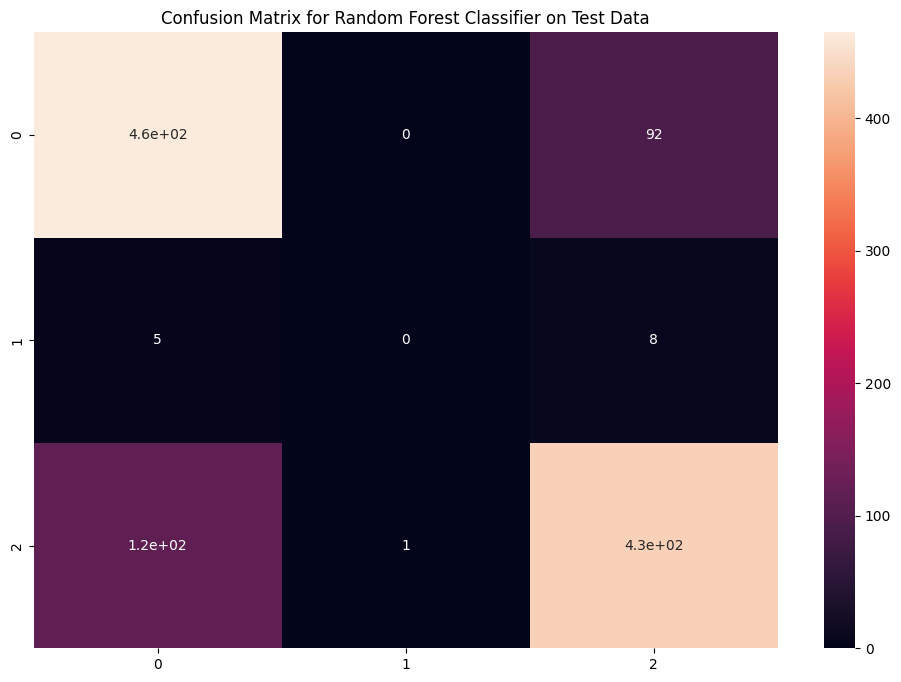

In [68]:
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Random Forest Classifier on Test Data")
plt.show()

In [69]:
# Training the models on whole data
final_svm_model = SVC()
final_rf_model = RandomForestClassifier(random_state=18)
final_svm_model.fit(X, y)
final_rf_model.fit(X, y)
# Reading the test data
test_data = pd.read_csv("output_1.csv").dropna(axis=1)
 

In [70]:
test_X = test_data.iloc[:, 7:-1]
test_Y = le.transform(test_data.iloc[:, -1])
print(test_Y)

[0 2 2 ... 0 0 0]


In [71]:

# Making prediction by take mode of predictions 
# made by all the classifiers
svm_preds = final_svm_model.predict(test_X)
rf_preds = final_rf_model.predict(test_X)

In [72]:
# import requests
# response = requests.get("http://localhost:8001/signal/")
# print(response.status_code)
# data= response.json()
# print(data)
data = {'RECOMMENDATION': 'SELL', 'BUY': 0, 'SELL': 2, 'NEUTRAL': 9, 'COMPUTE': {'RSI': 'NEUTRAL', 'STOCH.K': 'NEUTRAL', 'CCI': 'NEUTRAL', 'ADX': 'NEUTRAL', 'AO': 'NEUTRAL', 'Mom': 'SELL', 'MACD': 'SELL', 'Stoch.RSI': 'NEUTRAL', 'W%R': 'NEUTRAL', 'BBP': 'NEUTRAL', 'UO': 'NEUTRAL'}, 'Recommend.Other': -0.18181818, 'Recommend.All': -0.55757576, 'Recommend.MA': -0.93333333, 'RSI': 31.34628773, 'RSI[1]': 34.1396156, 'Stoch.K': 3.87649259, 'Stoch.D': 20.14166315, 'Stoch.K[1]': 18.1051663, 'Stoch.D[1]': 35.66313798, 'CCI20': -255.59767501, 'CCI20[1]': -242.34060171, 'ADX': 20.41659644, 'ADX+DI': 13.23635959, 'ADX-DI': 27.48847448, 'ADX+DI[1]': 14.05410878, 'ADX-DI[1]': 25.03251932, 'AO': -0.00092024, 'AO[1]': -0.00067997, 'Mom': -0.00146, 'Mom[1]': -0.00139, 'MACD.macd': -0.00047056, 'MACD.signal': -0.00031635, 'Rec.Stoch.RSI': 0, 'Stoch.RSI.K': 0, 'Rec.WR': 0, 'W.R': -96.65427509, 'Rec.BBPower': 0, 'BBPower': -0.0023458, 'Rec.UO': 0, 'UO': 38.6363835, 'close': 1.05343, 'EMA5': 1.05421729, 'SMA5': 1.054536, 'EMA10': 'SELL', 'SMA10': 'SELL', 'EMA20': 'SELL', 'SMA20': 'SELL', 'EMA30': 'SELL', 'SMA30': 'SELL', 'EMA50': 'SELL', 'SMA50': 'SELL', 'EMA100': 'SELL', 'SMA100': 'SELL', 'EMA200': 'SELL', 'SMA200': 'SELL', 'Rec.Ichimoku': 0, 'Ichimoku.BLine': 1.055215, 'Rec.VWMA': -1, 'VWMA': 'SELL', 'Rec.HullMA9': -1, 'HullMA9': 1.05381426, 'Pivot.M.Classic.S3': 1.04433667, 'Pivot.M.Classic.S2': 1.05052667, 'Pivot.M.Classic.S1': 1.05394333, 'Pivot.M.Classic.Middle': 1.05671667, 'Pivot.M.Classic.R1': 1.06013333, 'Pivot.M.Classic.R2': 1.06290667, 'Pivot.M.Classic.R3': 1.06909667, 'Pivot.M.Fibonacci.S3': 1.05052667, 'Pivot.M.Fibonacci.S2': 1.05289125, 'Pivot.M.Fibonacci.S1': 1.05435209, 'Pivot.M.Fibonacci.Middle': 1.05671667, 'Pivot.M.Fibonacci.R1': 1.05908125, 'Pivot.M.Fibonacci.R2': 1.06054209, 'Pivot.M.Fibonacci.R3': 1.06290667, 'Pivot.M.Camarilla.S3': 1.05565775, 'Pivot.M.Camarilla.S2': 1.05622517, 'Pivot.M.Camarilla.S1': 1.05679258, 'Pivot.M.Camarilla.Middle': 1.05671667, 'Pivot.M.Camarilla.R1': 1.05792742, 'Pivot.M.Camarilla.R2': 1.05849483, 'Pivot.M.Camarilla.R3': 1.05906225, 'Pivot.M.Woodie.S3': 1.048105, 'Pivot.M.Woodie.S2': 1.0507025, 'Pivot.M.Woodie.S1': 1.054295, 'Pivot.M.Woodie.Middle': 1.0568925, 'Pivot.M.Woodie.R1': 1.060485, 'Pivot.M.Woodie.R2': 1.0630825, 'Pivot.M.Woodie.R3': 1.066675, 'Pivot.M.Demark.S1': 1.05533, 'Pivot.M.Demark.Middle': 1.05741, 'Pivot.M.Demark.R1': 1.06152, 'open': 1.05378, 'P.SAR': 1.055938, 'BB.lower': 1.05382287, 'BB.upper': 1.05660413, 'AO[2]': -0.00054329, 'volume': 6216, 'change': -0.04080238, 'low': 1.05334, 'high': 1.05392, 'Ichimoku': 'NEUTRAL', 'HullMA': 'SELL'}
# print(type(data[0]))
# print(data[0])
print(data)
input_data = {
    'trend_macd': [data['MACD.macd']],
    'trend_macd_signal': [data['MACD.signal']],
    'trend_adx': [data['ADX']],
    'trend_cci': [data['CCI20']],
    'momentum_rsi': [data['RSI']],
    'momentum_stoch': [data['Stoch.K']],
    'momentum_stoch_signal': [data['Stoch.D']],
    'momentum_uo': (data['UO']),
    'momentum_wr': (data['W.R']),
    'momentum_ao': (data['AO'])
}
print(input_data)
input_data = pd.DataFrame(input_data)
print(input_data)

{'RECOMMENDATION': 'SELL', 'BUY': 0, 'SELL': 2, 'NEUTRAL': 9, 'COMPUTE': {'RSI': 'NEUTRAL', 'STOCH.K': 'NEUTRAL', 'CCI': 'NEUTRAL', 'ADX': 'NEUTRAL', 'AO': 'NEUTRAL', 'Mom': 'SELL', 'MACD': 'SELL', 'Stoch.RSI': 'NEUTRAL', 'W%R': 'NEUTRAL', 'BBP': 'NEUTRAL', 'UO': 'NEUTRAL'}, 'Recommend.Other': -0.18181818, 'Recommend.All': -0.55757576, 'Recommend.MA': -0.93333333, 'RSI': 31.34628773, 'RSI[1]': 34.1396156, 'Stoch.K': 3.87649259, 'Stoch.D': 20.14166315, 'Stoch.K[1]': 18.1051663, 'Stoch.D[1]': 35.66313798, 'CCI20': -255.59767501, 'CCI20[1]': -242.34060171, 'ADX': 20.41659644, 'ADX+DI': 13.23635959, 'ADX-DI': 27.48847448, 'ADX+DI[1]': 14.05410878, 'ADX-DI[1]': 25.03251932, 'AO': -0.00092024, 'AO[1]': -0.00067997, 'Mom': -0.00146, 'Mom[1]': -0.00139, 'MACD.macd': -0.00047056, 'MACD.signal': -0.00031635, 'Rec.Stoch.RSI': 0, 'Stoch.RSI.K': 0, 'Rec.WR': 0, 'W.R': -96.65427509, 'Rec.BBPower': 0, 'BBPower': -0.0023458, 'Rec.UO': 0, 'UO': 38.6363835, 'close': 1.05343, 'EMA5': 1.05421729, 'SMA5': 

In [73]:
rf = final_rf_model.predict(input_data)
print(rf[0])
svm = final_svm_model.predict(input_data)
print(svm[0])

SELL
SELL
